In [2]:
!pip install scikit-fuzzy

   ---------------------------------------- 0.0/920.8 kB ? eta -:--:--
   ---------------------------------------- 0.0/920.8 kB ? eta -:--:--
   ---------------------------------------- 0.0/920.8 kB ? eta -:--:--
   ---------------------------------------- 0.0/920.8 kB ? eta -:--:--
   ----------- ---------------------------- 262.1/920.8 kB ? eta -:--:--
   ---------------------- ----------------- 524.3/920.8 kB 1.5 MB/s eta 0:00:01
   ---------------------------------- ----- 786.4/920.8 kB 1.3 MB/s eta 0:00:01
   ---------------------------------------- 920.8/920.8 kB 1.2 MB/s  0:00:01


In [3]:
# Importing necessary libraries
import numpy as np
import skfuzzy as fuzz
import matplotlib.pyplot as plt

## 0. Visualizing Common Membership Functions
This section introduces commonly used fuzzy membership functions using the `skfuzzy` library:
- **Triangular** (`trimf`)
- **Trapezoidal** (`trapmf`)
- **Gaussian** (`gaussmf`)
- **Generalized bell** (`gbellmf`)
- **Singleton** (approximated using a sharp narrow Gaussian function)

Understanding the shape and parameters of each function is essential to design appropriate fuzzy sets.

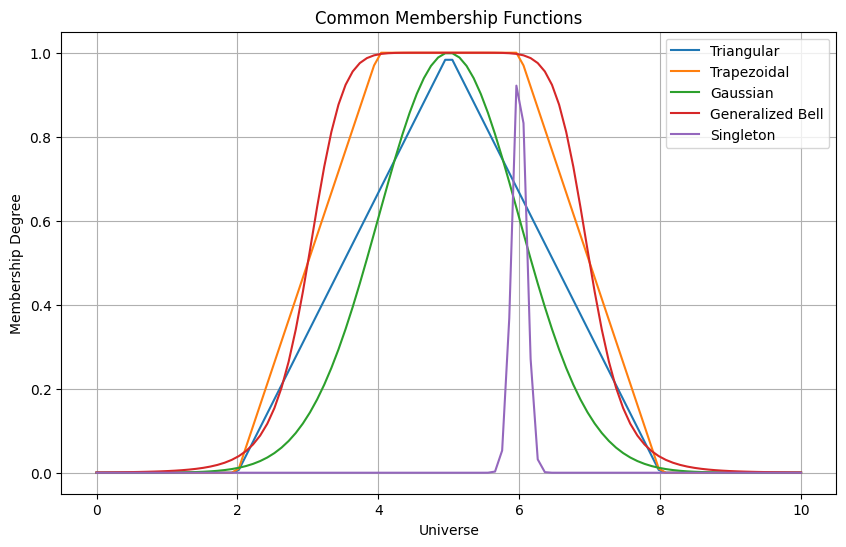

In [4]:
x = np.linspace(0, 10, 100)
tri = fuzz.trimf(x, [2, 5, 8])
trap = fuzz.trapmf(x, [2, 4, 6, 8])
gauss = fuzz.gaussmf(x, 5, 1.0)
bell = fuzz.gbellmf(x, 2, 4, 5)
singleton = fuzz.gaussmf(x, 6, 0.1)

plt.figure(figsize=(10,6))
plt.plot(x, tri, label='Triangular')
plt.plot(x, trap, label='Trapezoidal')
plt.plot(x, gauss, label='Gaussian')
plt.plot(x, bell, label='Generalized Bell')
plt.plot(x, singleton, label='Singleton')
plt.title('Common Membership Functions')
plt.xlabel('Universe')
plt.ylabel('Membership Degree')
plt.legend()
plt.grid(True)
plt.show()

# Fuzzy Sets and Operations in Python
### Using `scikit-fuzzy (skfuzzy)` Library

**Lecture Objectives:**
- Understand fuzzy sets and membership functions.
- Define and visualize common fuzzy membership functions.
- Perform fuzzy operations: union, intersection, complement.
- Use alpha-cuts and evaluate membership degrees.
- Apply exercises after each section.

## 1. Defining Fuzzy Sets and Membership Functions

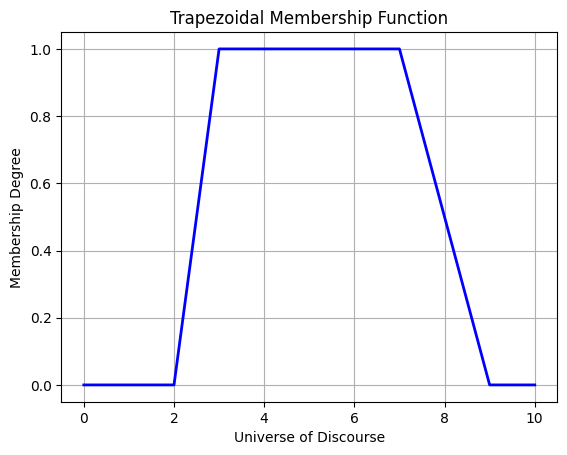

In [8]:
# Define universe of discourse
x = np.arange(0, 10.1, 0.1)

# Define fuzzy set using trapezoidal membership function
params = [2, 3, 7, 9]
y = fuzz.trapmf(x, params)

# Plot
plt.figure()
plt.plot(x, y, 'b', linewidth=2)
plt.title('Trapezoidal Membership Function')
plt.xlabel('Universe of Discourse')
plt.ylabel('Membership Degree')
plt.grid(True)
plt.show()

**Exercise 1:**
Define and plot two other types of membership functions (e.g., `trimf`, `gaussmf`) in the domain `[-5, 8]`.

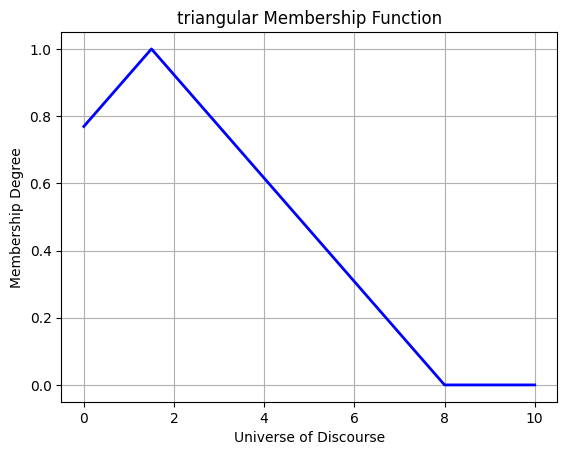

In [18]:
# Write your solution here

# Define fuzzy set using trapezoidal membership function
params = [-5, 1.5, 8]
y = fuzz.trimf(x, params)

# Plot
plt.figure()
plt.plot(x, y, 'b', linewidth=2)
plt.title('triangular Membership Function')
plt.xlabel('Universe of Discourse')
plt.ylabel('Membership Degree')
plt.grid(True)
plt.show()

## 2. Evaluating Membership Degrees

x1 = 2.75 has membership degree u1 = 0.81


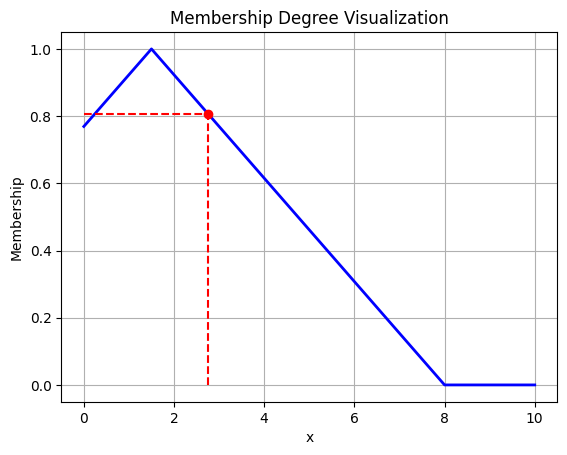

In [19]:
# Example: find membership degree of x = 2.75
x1 = 2.75
u1 = fuzz.interp_membership(x, y, x1)
print(f"x1 = {x1} has membership degree u1 = {u1:.2f}")

# Plot point
plt.plot(x, y, 'b', linewidth=2)
plt.plot([x1, x1], [0, u1], 'r--')
plt.plot([0, x1], [u1, u1], 'r--')
plt.plot(x1, u1, 'ro')
plt.title('Membership Degree Visualization')
plt.xlabel('x')
plt.ylabel('Membership')
plt.grid(True)
plt.show()

**Exercise 2:**
Define a fuzzy set using `gaussmf`. Then compute and plot the membership degree for x = 4.5 and x = 6.

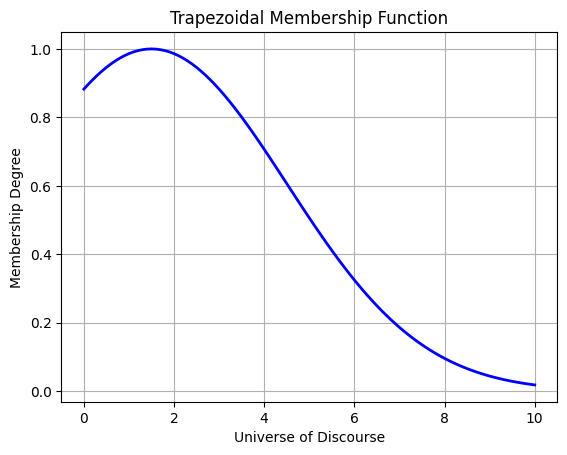

In [21]:
# Write your solution here
# Define fuzzy set using trapezoidal membership function
mean, sigma = 1.5, 3
y = fuzz.gaussmf(x, mean, sigma)

# Plot
plt.figure()
plt.plot(x, y, 'b', linewidth=2)
plt.title('Trapezoidal Membership Function')
plt.xlabel('Universe of Discourse')
plt.ylabel('Membership Degree')
plt.grid(True)
plt.show()

x1 = 4.5 has membership degree u1 = 0.61
x2 = 6 has membership degree u2 = 0.32


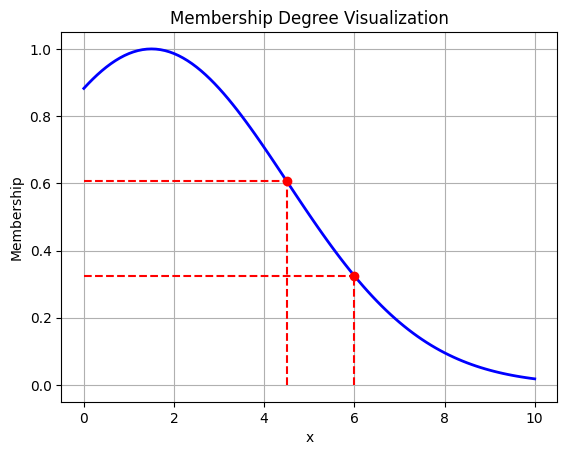

In [22]:
x1, x2 = 4.5, 6
u1, u2 = fuzz.interp_membership(x, y, x1), fuzz.interp_membership(x, y, x2)
print(f"x1 = {x1} has membership degree u1 = {u1:.2f}")
print(f"x2 = {x2} has membership degree u2 = {u2:.2f}")

# Plot point
plt.plot(x, y, 'b', linewidth=2)
plt.plot([x1, x1], [0, u1], 'r--')
plt.plot([0, x1], [u1, u1], 'r--')
plt.plot(x1, u1, 'ro')
plt.plot([x2, x2], [0, u2], 'r--')
plt.plot([0, x2], [u2, u2], 'r--')
plt.plot(x2, u2, 'ro')
plt.title('Membership Degree Visualization')
plt.xlabel('x')
plt.ylabel('Membership')
plt.grid(True)
plt.show()

## 3. Fuzzy Set Operations: Union, Intersection, Complement

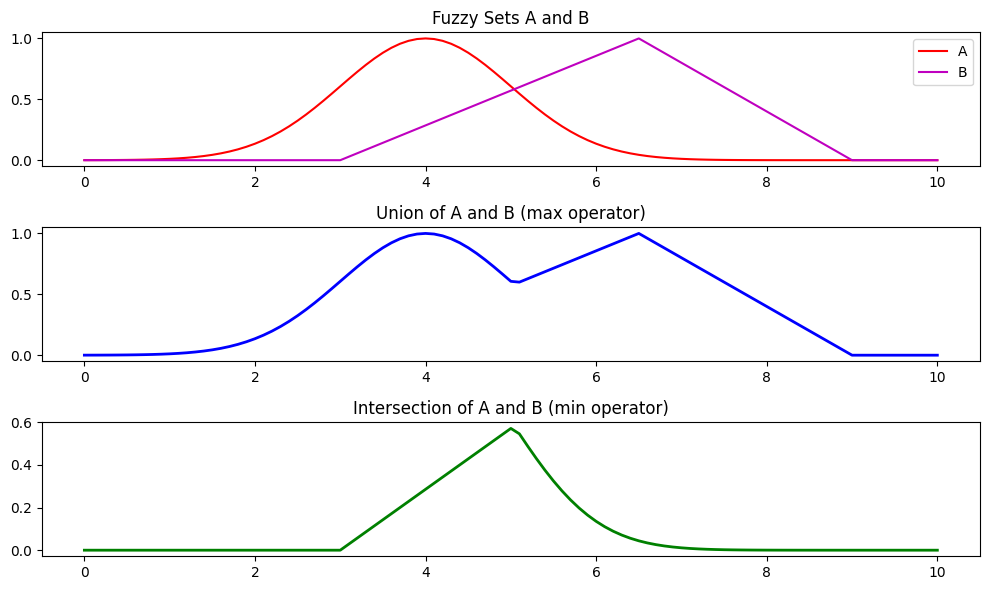

In [23]:
# Define universe of discourse
x = np.arange(0, 10.1, 0.1)

# Define two fuzzy sets
u1 = fuzz.gaussmf(x, 4, 1)
u2 = fuzz.trimf(x, [3, 6.5, 9])

# Union and Intersection
u_union = np.fmax(u1, u2)
u_intersect = np.fmin(u1, u2)

# Complement of u1
u1_comp = 1 - u1

# Plot all
plt.figure(figsize=(10, 6))
plt.subplot(3, 1, 1)
plt.plot(x, u1, 'r', label='A')
plt.plot(x, u2, 'm', label='B')
plt.title('Fuzzy Sets A and B')
plt.legend()

plt.subplot(3, 1, 2)
plt.plot(x, u_union, 'b', linewidth=2)
plt.title('Union of A and B (max operator)')

plt.subplot(3, 1, 3)
plt.plot(x, u_intersect, 'g', linewidth=2)
plt.title('Intersection of A and B (min operator)')

plt.tight_layout()
plt.show()

**Exercise 3.1:**
Define two new different fuzzy set (A,B) and compute (intersection, union, complement) and Plot the results.

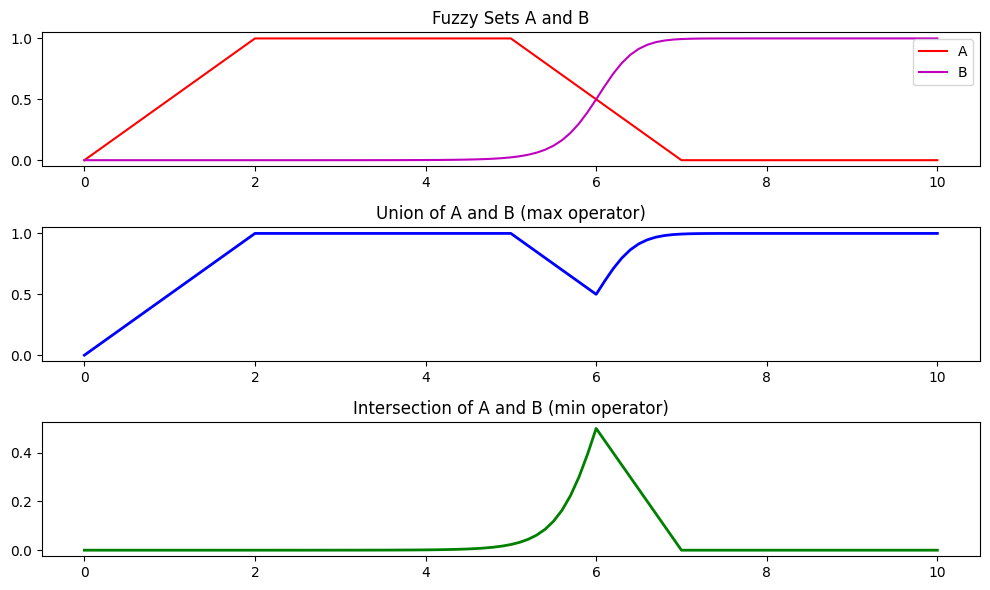

In [26]:
# Write your solution here
x = np.arange(0, 10.1, 0.1)

# Define two fuzzy sets
u1 = fuzz.trapmf(x, [0, 2, 5, 7])
u2 = fuzz.gbellmf(x, 3, 6.5, 9)

# Union and Intersection
u_union = np.fmax(u1, u2)
u_intersect = np.fmin(u1, u2)

# Complement of u1
u1_comp = 1 - u1

# Plot all
plt.figure(figsize=(10, 6))
plt.subplot(3, 1, 1)
plt.plot(x, u1, 'r', label='A')
plt.plot(x, u2, 'm', label='B')
plt.title('Fuzzy Sets A and B')
plt.legend()

plt.subplot(3, 1, 2)
plt.plot(x, u_union, 'b', linewidth=2)
plt.title('Union of A and B (max operator)')

plt.subplot(3, 1, 3)
plt.plot(x, u_intersect, 'g', linewidth=2)
plt.title('Intersection of A and B (min operator)')

plt.tight_layout()
plt.show()

**Exercise 3.2:**
Write code to plot the complement of fuzzy set B. Also, use `plt.text` to annotate the membership degrees at x = 4, 5, 6, 7 on the intersection graph.

In [ ]:
# Write your solution here

## 4. Alpha-Cuts
An alpha-cut is a crisp set that contains all elements of the fuzzy set that have a membership degree greater than or equal to a given alpha threshold.

Alpha-cut (alpha=0.5): [1.  1.1 1.2 1.3 1.4 1.5 1.6 1.7 1.8 1.9 2.  2.1 2.2 2.3 2.4 2.5 2.6 2.7
 2.8 2.9 3.  3.1 3.2 3.3 3.4 3.5 3.6 3.7 3.8 3.9 4.  4.1 4.2 4.3 4.4 4.5
 4.6 4.7 4.8 4.9 5.  5.1 5.2 5.3 5.4 5.5 5.6 5.7 5.8 5.9 6. ]


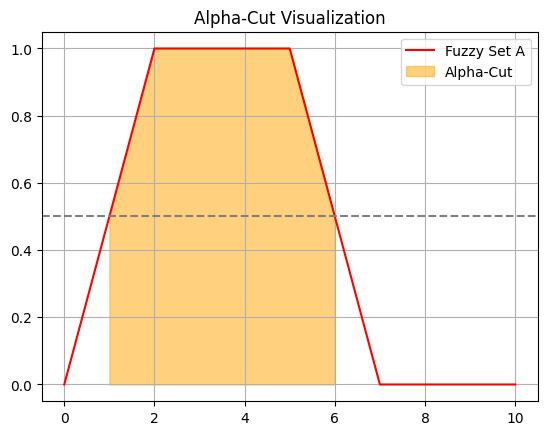

In [27]:
# Define universe of discourse
x = np.arange(0, 10.1, 0.1)

# Example alpha cut for alpha = 0.5
alpha = 0.5
alpha_cut = x[u1 >= alpha]
print(f"Alpha-cut (alpha=0.5): {alpha_cut}")

# Visual representation
plt.plot(x, u1, 'r', label='Fuzzy Set A')
plt.axhline(y=alpha, color='gray', linestyle='--')
plt.fill_between(x, 0, u1, where=(u1 >= alpha), color='orange', alpha=0.5, label='Alpha-Cut')
plt.legend()
plt.title('Alpha-Cut Visualization')
plt.grid(True)
plt.show()

**Exercise 4:**
Compute the alpha-cut for alpha values 0.3 and 0.7. Visualize both cuts. (for your previou fuzzy set A and B from the exercise 3.1)

Alpha-cut (alpha=0.3): [0.6 0.7 0.8 0.9 1.  1.1 1.2 1.3 1.4 1.5 1.6 1.7 1.8 1.9 2.  2.1 2.2 2.3
 2.4 2.5 2.6 2.7 2.8 2.9 3.  3.1 3.2 3.3 3.4 3.5 3.6 3.7 3.8 3.9 4.  4.1
 4.2 4.3 4.4 4.5 4.6 4.7 4.8 4.9 5.  5.1 5.2 5.3 5.4 5.5 5.6 5.7 5.8 5.9
 6.  6.1 6.2 6.3]
Alpha-cut (alpha=0.7): [1.4 1.5 1.6 1.7 1.8 1.9 2.  2.1 2.2 2.3 2.4 2.5 2.6 2.7 2.8 2.9 3.  3.1
 3.2 3.3 3.4 3.5 3.6 3.7 3.8 3.9 4.  4.1 4.2 4.3 4.4 4.5 4.6 4.7 4.8 4.9
 5.  5.1 5.2 5.3 5.4 5.5]


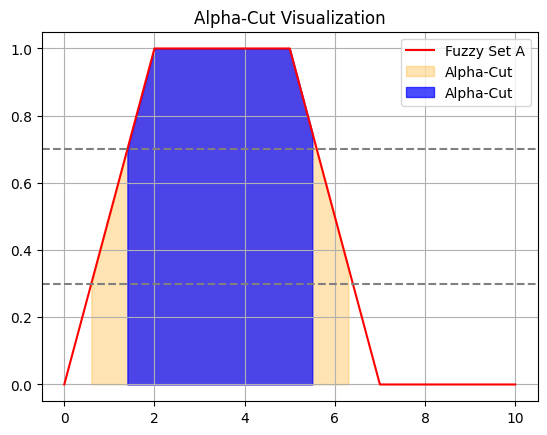

In [28]:
# Write your solution here
# Example alpha cut for alpha = 0.3
alpha = 0.3
alpha1 = 0.7
alpha_cut = x[u1 >= alpha]
alpha_cut1 = x[u1 >= alpha1]
print(f"Alpha-cut (alpha=0.3): {alpha_cut}")
print(f"Alpha-cut (alpha=0.7): {alpha_cut1}")

# Visual representation
plt.plot(x, u1, 'r', label='Fuzzy Set A')
plt.axhline(y=alpha, color='gray', linestyle='--')
plt.axhline(y=alpha1, color='gray', linestyle='--')
plt.fill_between(x, 0, u1, where=(u1 >= alpha), color='orange', alpha=alpha, label='Alpha-Cut')
plt.fill_between(x, 0, u1, where=(u1 >= alpha1), color='blue', alpha=alpha1, label='Alpha-Cut')
plt.legend()
plt.title('Alpha-Cut Visualization')
plt.grid(True)
plt.show()